# DLRM Architecture

## Paper Notes

- DLRM is a combination of the all the models that came before it.
- The dataset can be divided in to dense and sparse features.
- Let there be $n_1$ dense features and $n_2$ sparse features.
- The $n_1$ dense features are made to go through a MLP[Bottom MLP] which outputs a vector $D \in R^d$.
- The sparse features are embedded through an Embedding layer and become $e_1,e_2,...,e_{n_2} \in R^d$.
- There latent features of the sparse features can further optionally be passed through one more MLP.
- Basially both the latent feature sets get the same dimensions.
- Now, we take the second order feature interactions via dot product of each unique pair of $D,e_1,e_2,...,e_{n_2}$.

- The dot products are all scalars $d_1,d_2,...$.
- They are concatinated with the D vector, like, $[D,d_1,d_2,..]$.
- Now, this new vector is passed through a MLP[Top MLP].

### Few Implementation Details
- framework used: Pytorch
- Embedding: nn.Embedding
- Loss: BCEWithLogitsLoss

# Implementation - DLRM

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,log_loss,f1_score,accuracy_score,balanced_accuracy_score,average_precision_score
import seaborn as sns
import copy
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataloading

In [ ]:
train_ds=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_recommender2_3/train.csv")
test_ds=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset_recommender2_3/test.csv")

## Data Visualisation

In [ ]:
train_ds.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


In [ ]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   label                   40000 non-null  int64  
 1   integer_feature_1       32604 non-null  float64
 2   integer_feature_2       36524 non-null  float64
 3   integer_feature_3       30183 non-null  float64
 4   integer_feature_4       24005 non-null  float64
 5   integer_feature_5       24587 non-null  float64
 6   integer_feature_6       36473 non-null  float64
 7   integer_feature_7       38787 non-null  float64
 8   integer_feature_8       40000 non-null  int64  
 9   integer_feature_9       40000 non-null  int64  
 10  integer_feature_10      36473 non-null  float64
 11  integer_feature_11      24587 non-null  float64
 12  integer_feature_12      39889 non-null  float64
 13  integer_feature_13      30183 non-null  float64
 14  categorical_feature_1   38379 non-null

In [ ]:
train_ds.describe()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,integer_feature_10,integer_feature_11,integer_feature_12,integer_feature_13
count,40000.000000,32604.000000,36524.000000,30183.000000,24005.000000,24587.000000,36473.000000,38787.000000,40000.000000,40000.000000,36473.000000,24587.000000,3.988900e+04,30183.000000
mean,0.032000,35.691326,407.400641,7.116324,146.996626,22.337699,1.606010,0.159950,115.482225,10.040550,0.267074,4.154106,2.183603e+04,8.911440
std,0.176002,545.040254,703.383021,9.264465,625.116575,70.349743,6.210465,1.646236,389.820072,12.351223,0.542083,7.221938,7.756904e+04,14.744663
min,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000
25%,0.000000,3.000000,55.000000,2.000000,9.000000,2.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,6.010000e+02,2.000000
50%,0.000000,8.000000,177.000000,4.000000,32.000000,6.000000,0.000000,0.000000,5.000000,5.000000,0.000000,2.000000,2.786000e+03,4.000000
75%,0.000000,24.000000,471.000000,9.000000,96.000000,17.000000,1.000000,0.000000,53.000000,15.000000,0.000000,4.000000,1.143300e+04,11.000000
max,1.000000,65535.000000,8000.000000,491.000000,42898.000000,2107.000000,288.000000,102.000000,8177.000000,50.000000,7.000000,146.000000,2.068079e+06,539.000000


In [ ]:
CAT=[f"categorical_feature_{i}" for i in range(1,27,1)]
NUM=[f"integer_feature_{i}" for i in range(1,14,1)]



## Data Processing Pipeline

In [ ]:
MISSING_ID,RARE_ID=0,1

In [ ]:
def signed_log1p(x):
  return np.sign(x) * np.log1p(np.abs(x))

In [ ]:
class CTRPreprocessor:
    def __init__(self, min_count=5, clip_q=0.999):
        self.min_count = min_count
        self.clip_q = clip_q

    def fit(self, df):
        X = signed_log1p(df[NUM].astype(float))
        self.miss_cols_ = [c for c in NUM if df[c].isna().any()]
        self.lo_ = X.quantile(1 - self.clip_q)
        self.hi_ = X.quantile(self.clip_q)
        X = X.clip(self.lo_, self.hi_, axis=1)
        self.fill_ = X.median()
        X = X.fillna(self.fill_)
        self.mu_, self.sd_ = X.mean(), X.std().replace(0, 1)

        self.vocab_ = {}
        for c in CAT:
            vc = df[c].value_counts()
            keep = vc[vc >= self.min_count].index
            self.vocab_[c] = {v: i + 2 for i, v in enumerate(keep)}
        self.cardinalities_ = [len(self.vocab_[c]) + 2 for c in CAT]
        return self

    def transform(self, df):
        X = signed_log1p(df[NUM].astype(float))
        ind = df[self.miss_cols_].isna().astype("float32").values
        X = X.clip(self.lo_, self.hi_, axis=1).fillna(self.fill_)
        X = ((X - self.mu_) / self.sd_).astype("float32").values
        num = np.hstack([X, ind])

        cat = np.zeros((len(df), len(CAT)), dtype="int64")
        for j, c in enumerate(CAT):
            mapped = df[c].map(self.vocab_[c])
            cat[:, j] = np.where(df[c].isna(), MISSING_ID,mapped.fillna(RARE_ID)).astype("int64")
        y = df["label"].values.astype("float32") if "label" in df else None
        return num, cat, y

    def emb_dims(self, cap=16):
        return [int(min(cap, round(1.6 * n ** 0.56))) for n in self.cardinalities_]

In [ ]:
def load_splits(path, val_size=0.2, seed=42, **kw):
    df = pd.read_csv(path)
    tr, va = train_test_split(df, test_size=val_size, stratify=df["label"], random_state=seed)
    pp = CTRPreprocessor(**kw).fit(tr)
    return pp, pp.transform(tr), pp.transform(va)

In [ ]:
path="/content/drive/MyDrive/Colab Notebooks/dataset_recommender2_3/train.csv"
pp,(xn_tr,xc_tr,y_tr),(xn_va,xc_va,y_va)=load_splits(path)
xn_te,xc_te,y_te=pp.transform(test_ds)
xn_te.shape,xc_te.shape,y_te.shape

((10000, 24), (10000, 26), (10000,))

## Data Loader

In [ ]:
train_dataset=DataLoader(TensorDataset(torch.tensor(xn_tr),torch.tensor(xc_tr),torch.tensor(y_tr)),batch_size=512,shuffle=True)
val_dataset=DataLoader(TensorDataset(torch.tensor(xn_va),torch.tensor(xc_va),torch.tensor(y_va)),batch_size=512)
test_dataset=DataLoader(TensorDataset(torch.tensor(xn_te),torch.tensor(xc_te),torch.tensor(y_te)),batch_size=512)

## Model Architecture

In [ ]:
class DLRM(nn.Module):
    def __init__(self,pp,bot_layers=(128,64),top_layers=(128,64),dropout=0.2,d0=16,n_dense=24):
      super().__init__()

      # self.hidden=hidden
      # self.dropout=dropout
      self.embs=nn.ModuleList([nn.Embedding(c,d0) for c in pp.cardinalities_])
      d1=xn_tr.shape[1]
      # self.cross=nn.ModuleList([nn.Linear(d0,d0) for _ in range(n_cross)])
      m=len(pp.cardinalities_)+1
      self.mask=torch.triu(torch.ones(m,m),diagonal=1).bool()
      layers=[]
      d=n_dense

      for h in bot_layers:
        layers.append(nn.Linear(d,h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        d=h
      layers.append(nn.Linear(d,d0))
      layers.append(nn.BatchNorm1d(d0))
      layers.append(nn.ReLU())
      self.bot=nn.Sequential(*layers)
      d=d0+(m*(m-1))//2
      layers=[]
      for h in top_layers:
        layers.append(nn.Linear(d,h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        d=h
      layers.append(nn.Linear(d,1))
      self.top=nn.Sequential(*layers)

      # self.final=nn.Linear(d+ (d0 if n_cross else 0),1)

    def forward(self,xn,xc):
      E=[w(xc[:,i]) for i,w in enumerate(self.embs)]

      D=self.bot(xn)

      T=torch.stack([D]+E,dim=1)
      Z=torch.bmm(T,T.transpose(1,2))

      dn=Z[:,self.mask]
      concat_dn=torch.cat([D,dn],1)
      return self.top(concat_dn).squeeze(1)



## Model parameters List

In [ ]:
configs = {
  "DLRM small":  dict(bot_layers=(64,32),top_layers=(64,1)),
  "DLRM medium": dict(bot_layers=(128, 64,32),top_layers=(128,64)),
  "DLRM large":  dict(bot_layers=(256, 128, 64,32),top_layers=(256,128,64,32), dropout=0.3),
}

## Prediction and fit functions

In [ ]:
def predict(m,loader):
  m.eval()
  p=[]
  with torch.no_grad():
    for xn,xc,_ in loader:
      p.append(torch.sigmoid(m(xn.to(device),xc.to(device))).cpu())
  return torch.cat(p).numpy()

In [ ]:
def fit(m,epochs=30,patience=5):
  m.to(device)
  optim=torch.optim.Adam(m.parameters(),lr=1e-4)
  loss_fn=nn.BCEWithLogitsLoss()
  history={"train":[],"val":[]}
  best=1e9
  bad=0
  for epoch in range(epochs):
    tot=0
    for xn,xc,y in train_dataset:
      xn,xc,y=xn.to(device),xc.to(device),y.to(device)
      optim.zero_grad()
      loss=loss_fn(m(xn,xc),y)
      loss.backward()
      optim.step()
      tot+=loss.item()*len(y)
    v=log_loss(y_va,predict(m,val_dataset))
    history["train"].append(tot/len(y_tr))
    history["val"].append(v)

    if v<best:
      best=v
      state=copy.deepcopy(m.state_dict())
      bad=0
    else:
      bad+=1
      if bad>=patience:
        break
  m.load_state_dict(state)
  return m,history


## Model training and Comparison

In [ ]:
models,history,rows={},{},[]
t=0.05
for name,cnf in configs.items():
  torch.manual_seed(0)
  models[name],history[name]=fit(DLRM(pp,**cnf,),epochs=30)
  p=predict(models[name],val_dataset)
  roc=roc_auc_score(y_va,p)
  log=log_loss(y_va,p)
  f1=f1_score(y_va,p>t)
  acc=accuracy_score(y_va,p>t)
  ba=balanced_accuracy_score(y_va,p>t)
  pr_auc=average_precision_score(y_va,p)
  rows.append([name,roc,log,f1,acc,ba,pr_auc])
  print(f"Model :{name}|roc={roc}|log_loss={log}|f1_score={f1}|acc={acc}")
  print(f"balanced_acc={ba}|pr-auc={pr_auc}")
  print("-"*10)

data=pd.DataFrame(rows,columns=["model","roc","log","f1","acc","ba","pr_auc"])
print(data)

Model :DLRM small|roc=0.6725711034349173|log_loss=0.13825192773373238|f1_score=0.10597958191541079|acc=0.770125
balanced_acc=0.603644757231405|pr-auc=0.06697769003551932
----------
Model :DLRM medium|roc=0.6902652456740702|log_loss=0.13441240735998777|f1_score=0.11846001974333663|acc=0.77675
balanced_acc=0.6278409090909092|pr-auc=0.08924728246706222
----------
Model :DLRM large|roc=0.6778297109052169|log_loss=0.1359731289406208|f1_score=0.11124121779859485|acc=0.81025
balanced_acc=0.5979306559917356|pr-auc=0.06987617225628091
----------
         model       roc       log        f1       acc        ba    pr_auc
0   DLRM small  0.672571  0.138252  0.105980  0.770125  0.603645  0.066978
1  DLRM medium  0.690265  0.134412  0.118460  0.776750  0.627841  0.089247
2   DLRM large  0.677830  0.135973  0.111241  0.810250  0.597931  0.069876


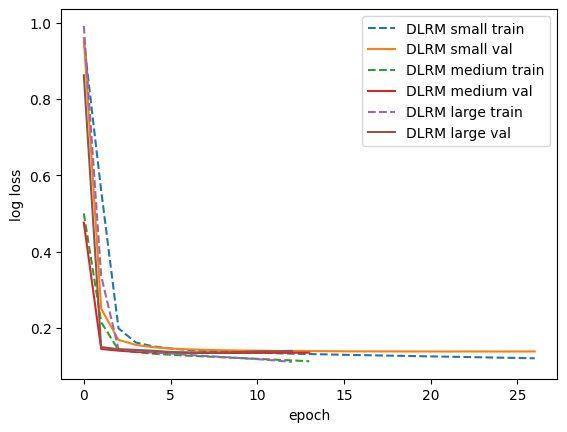

In [ ]:
for n, h in history.items():
    plt.plot(h["train"], "--", label=n+" train"); plt.plot(h["val"], label=n+" val")
plt.xlabel("epoch"); plt.ylabel("log loss"); plt.legend()